---->   Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

----->  Load Preprocessed Dataset

In [2]:
data = pd.read_csv("preprocessed_earthquake_data.csv")

print("Dataset Shape:", data.shape)
data.head()

Dataset Shape: (7585, 18)


,place,mag,magType,type,time,longitude,latitude,depth_km,sig,net,nst,dmin,rms,gap,year,month,day,magnitude_level
0,"113 km W of Petrolia, CA",2.56,md,earthquake,2025-02-11 14:34:38.190,-125.614334,40.216499,4.95,101,nc,14.0,0.97600,0.12,325.0,2025.0,2.0,11.0,Low
1,"9 km N of Taft, CA",1.54,ml,earthquake,2025-02-11 14:28:19.490,-119.456833,35.225167,18.24,36,ci,31.0,0.08479,0.20,116.0,2025.0,2.0,11.0,Low
2,"58 km WNW of Petrolia, CA",2.84,md,earthquake,2025-02-11 14:24:27.270,-124.964500,40.401165,4.20,124,nc,30.0,0.48850,0.37,274.0,2025.0,2.0,11.0,Low
3,"24 km NNW of Searles Valley, CA",1.49,ml,earthquake,2025-02-11 14:24:22.730,-117.515663,35.967335,4.01,34,ci,19.0,0.11100,0.16,83.0,2025.0,2.0,11.0,Low
4,"12 km WNW of Anza, CA",0.56,ml,earthquake,2025-02-11 14:12:30.720,-116.803167,33.584500,8.69,5,ci,25.0,0.05820,0.16,69.0,2025.0,2.0,11.0,Low


---------->    Create Target Variable

In [3]:
data['mag_category'] = pd.cut(
    data['mag'],
    bins=[0,2.5,4.5,10],
    labels=[0,1,2],
    include_lowest=True
)

data['mag_category'] = data['mag_category'].astype(float).fillna(0).astype(int)

print(data[['mag','mag_category']].head())

    mag  mag_category
0  2.56             1
1  1.54             0
2  2.84             1
3  1.49             0
4  0.56             0


------->     Select Features

In [4]:
features = ['latitude','longitude','depth_km','sig']

X = data[features]

y = data['mag_category']

------->   Train-Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (6068, 4)
Testing size: (1517, 4)


-------> Logistic Regression Model

In [6]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

log_acc = accuracy_score(y_test, log_pred)

print("Logistic Regression Accuracy:", log_acc)

Logistic Regression Accuracy: 0.998022412656559


----->  Decision Tree Model

In [7]:
tree_model = DecisionTreeClassifier()

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

dt_acc = accuracy_score(y_test, tree_pred)

print("Decision Tree Accuracy:", dt_acc)

Decision Tree Accuracy: 0.998681608437706


------>  Random Forest Model

In [8]:
rf_model = RandomForestClassifier()

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.998681608437706


---->  Gradient Boosting Model

In [9]:
gb_model = GradientBoostingClassifier(
    learning_rate=0.05,
    max_depth=8,
    n_estimators=300,
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

gb_acc = accuracy_score(y_test, gb_pred)

print("Gradient Boosting Accuracy:", gb_acc)

Gradient Boosting Accuracy: 0.998681608437706


-----> Model Accuracy Comparison Graph

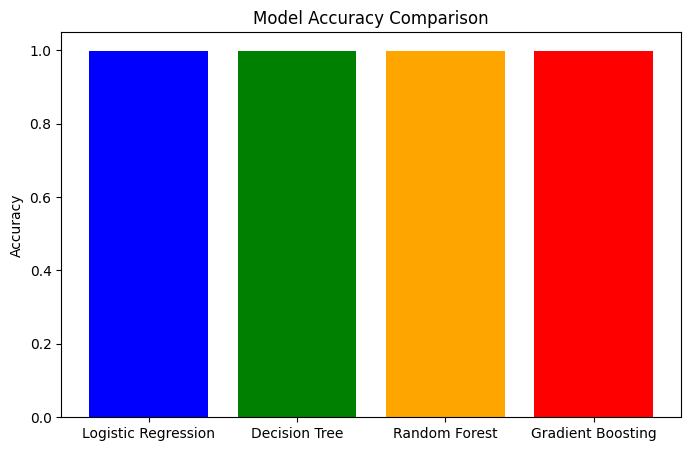

In [10]:
models = ['Logistic Regression','Decision Tree','Random Forest','Gradient Boosting']

accuracy = [log_acc, dt_acc, rf_acc, gb_acc]

plt.figure(figsize=(8,5))

plt.bar(models, accuracy, color=['blue','green','orange','red'])

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.show()

----->  Confusion Matrix

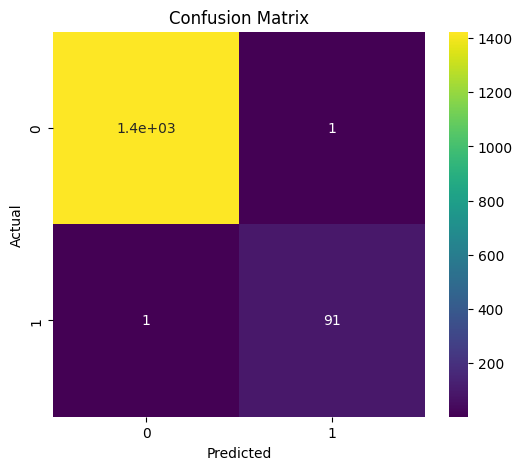

In [11]:
cm = confusion_matrix(y_test, gb_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, cmap="viridis")

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

------> Feature Importance Graph

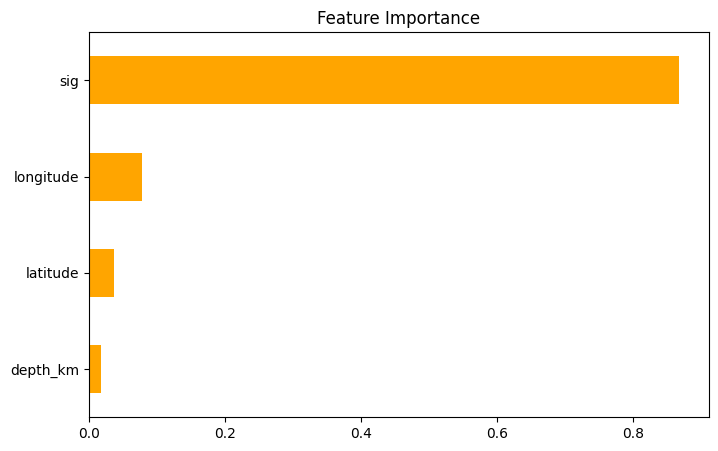

In [12]:
importance = rf_model.feature_importances_

feat_imp = pd.Series(importance, index=X.columns)

plt.figure(figsize=(8,5))

feat_imp.sort_values().plot(kind='barh', color='orange')

plt.title("Feature Importance")

plt.show()

--> Manual Prediction Test

In [13]:
sample = pd.DataFrame(
    [[7.02,10.0,9.0,8.0]],
    columns=['latitude','longitude','depth_km','sig']
)

prediction = gb_model.predict(sample)

print("Predicted Magnitude Category:", prediction)

Predicted Magnitude Category: [0]
